<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_C8_Ejercicio_Integrador_y_Foro_Obligatorio_(SV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sección 4: Ejercicio Integrador y Publicación en el Foro Obligatorio

**Objetivo**: Aplicar los conceptos de Regresión Logística y Regresión Múltiple en un caso práctico, evaluar los resultados y compartir las conclusiones en el foro.

**4.1. Ejercicio Integrador**

**Contexto**: Trabajas en una empresa de seguros y necesitas desarrollar modelos para:

* Predecir si un cliente presentará un reclamo (Sí/No) → Regresión Logística.
* Estimar el monto del reclamo en dólares → Regresión Múltiple.

**Dataset para el ejercicio**

| Cliente | Edad | Ingresos (USD) | Historial de Accidentes | Monto Reclamo (USD) | Reclamo (Sí/No) |
|---------|------|----------------|-------------------------|---------------------|-----------------|
| 1       | 25   | 30000          | 1                       | 5000                | Sí              |
| 2       | 40   | 55000          | 0                       | 0                   | No              |
| 3       | 32   | 42000          | 1                       | 7500                | Sí              |
| 4       | 50   | 60000          | 0                       | 0                   | No              |
| 5       | 28   | 37000          | 1                       | 6500                | Sí              |
| 6       | 45   | 52000          | 0                       | 0                   | No              |

**Tareas a realizar**

1. Preprocesamiento: Convertir "Reclamo" a numérico (0=No, 1=Sí). Dividir en entrenamiento (80%) y prueba (20%).
2. Regresión Logística: Variables predictoras: Edad, Ingresos, Historial de Accidentes. Evaluar con Matriz de Confusión y Precisión.
3. Regresión Múltiple: Mismas variables predictoras. Evaluar con R², MSE y MAE.
4. Interacción con IA (LLM): Consulta sugerida: "Tengo un dataset de aseguradoras. ¿Qué estrategias de modelado recomendarías para predecir el monto de un reclamo?"



---- Escalamos los datos ----



,Edad,Ingresos,Historial_Accidentes,Monto_Reclamo,Reclamo
0,-1.289242,-1.518653,1.0,0.564288,1.0
1,0.368355,0.854242,-1.0,-0.974679,-1.0
2,-0.515697,-0.379663,1.0,1.333772,1.0
3,1.473419,1.328821,-1.0,-0.974679,-1.0
4,-0.957722,-0.854242,1.0,1.025978,1.0
5,0.920887,0.569495,-1.0,-0.974679,-1.0


--- Regresión Logística ---


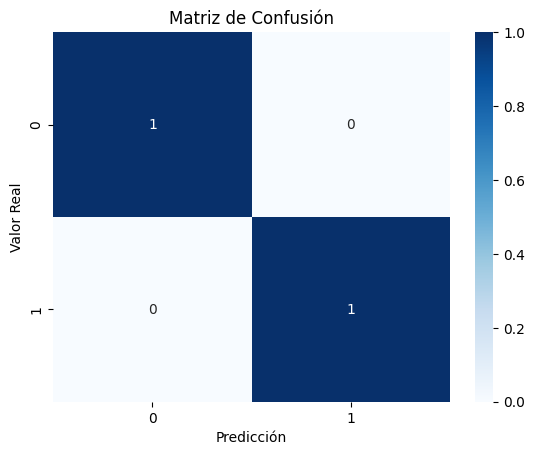


--- Evaluación Regresión Logística ---
Precisión: 1.00
Matriz de Confusión:
[[1 0]
 [0 1]]

--- Evaluación Regresión Múltiple ---
R²:  -4.69
MSE: 3.37
MAE: 1.68


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, r2_score,
                             mean_squared_error, mean_absolute_error)

# Dataset
data = {
    "Edad":                 [25, 40, 32, 50, 28, 45],
    "Ingresos":             [30000, 55000, 42000, 60000, 37000, 52000],
    "Historial_Accidentes": [1, 0, 1, 0, 1, 0],
    "Monto_Reclamo":        [5000, 0, 7500, 0, 6500, 0],
    "Reclamo":              ['Sí', 'No', 'Sí', 'No', 'Sí', 'No']
}
df = pd.DataFrame(data)

# Convertir "Reclamo" a numérico (0=No, 1=Sí)
#le = LabelEncoder()
#df['Reclamo'] = le.fit_transform(df['Reclamo'])

df["Reclamo"] = df["Reclamo"].map({'Sí': 1, 'No': 0})

print('\n---- Escalamos los datos ----\n')
columnas_numericas = ["Edad", "Ingresos", "Historial_Accidentes", "Monto_Reclamo", "Reclamo"]
scaler = StandardScaler()
df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])
display(df)

# Definiimos variables y dividimos en Entrenamiento (80%) y Prueba (20%)
X = df[["Edad", "Ingresos", "Historial_Accidentes"]]
y_c = df["Reclamo"]        # Variable para Clasificación
y_r = df["Monto_Reclamo"]  # Variable para Regresión

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X, y_c, test_size=0.2, random_state=42)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X, y_r, test_size=0.2, random_state=42)

# ---- Regresión Logística - Modelo Clasificación Binaria
log_model = LogisticRegression().fit(X_tr_c, y_tr_c) # Entrena el modelo
y_pred_c = log_model.predict(X_te_c) # Realizar predicciones


# Evaluación con Matriz de Confusión y Precisión
print("\n--- Regresión Logística ---")
cm = confusion_matrix(y_te_c, y_pred_c)

# Graficamos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

print("\n--- Evaluación Regresión Logística ---")
print(f"Precisión: {accuracy_score(y_te_c, y_pred_c):.2f}")
print("Matriz de Confusión:")
print(confusion_matrix(y_te_c, y_pred_c))


# ---- Regresión Múltiple
reg_model = LinearRegression().fit(X_tr_r, y_tr_r)  # Entrenar el modelo
y_pred_r = reg_model.predict(X_te_r)  # Realizar predicciones

# Evaluación con R², MSE y MAE
print("\n--- Evaluación Regresión Múltiple ---")
# Evalúa en modelo con R², MSE y MAE.
print(f"R²:  {r2_score(y_te_r, y_pred_r):.2f}")
print(f"MSE: {mean_squared_error(y_te_r, y_pred_r):.2f}")
print(f"MAE: {mean_absolute_error(y_te_r, y_pred_r):.2f}")

En cuanto a los resultados de la Regresión Logística, si bien el valor de Precisión=1 indica una clasificación lograda en la totalidad de los casos evaluados, hay que tener en cuenta que se trata de un conjunto de prueba muy pequeño, lo cual no garantiza el comportamiento real ddel modelo y hay posibilidad de sobreajuste (overfitting). La Matriz de confusión muestra que los casos fueron identificados correctamente, tengamos en cuenta que sólo fueron dos valores para el entrenamiento.

En cuanto a los resultados d e Regresión Múltiple, el valor de R2=-4.69 indica que el modelo no tiene un buen desempeño. El valorde MSE=3.37 indica que existen valores altos entre los valores reales y los estimados. El vlaord e MAE=1.68 indica que las predicciones se alejan aproximadamente 1.68 unidades respecto al valor real.

# 4. Interacción con IA (LLM): Consulta sugerida: "Tengo un dataset de aseguradoras. ¿Qué estrategias de modelado recomendarías para predecir el monto de un reclamo?"

## Estrategias de modelado para predecir el monto de un reclamo en aseguradoras

El objetivo es predecir cuánto dinero costará un reclamo utilizando información de clientes, vehículos y antecedentes.  
Como el monto del reclamo es un valor numérico, se trata de un problema de **regresión**.

---

## Variables que podrían utilizarse

| Tipo de variable | Ejemplos |
|---|---|
| Datos del cliente | Edad, ingresos, antigüedad |
| Vehículo | Marca, modelo, año |
| Historial | Accidentes previos, multas |
| Póliza | Tipo de cobertura, franquicia |
| Reclamo | Tipo y gravedad del accidente |

---

## Estrategias de modelado recomendadas

| Modelo | ¿Para qué sirve? | Ventajas | Desventajas |
|---|---|---|---|
| Regresión Lineal | Predecir montos con relaciones simples | Fácil de interpretar | Sensible a outliers |
| Random Forest | Detectar relaciones complejas | Robusto y preciso | Menos interpretable |
| XGBoost / Gradient Boosting | Mejorar precisión predictiva | Muy alto rendimiento | Más complejo |
| Gamma / Tweedie Regression | Modelar reclamos típicos de seguros | Ideal para datos asimétricos | Requiere mayor conocimiento |
| Modelo en dos etapas | Predecir si habrá reclamo y luego cuánto costará | Más realista | Más difícil de implementar |

---

## Problemas comunes en datasets de seguros

| Problema | Consecuencia | Solución |
|---|---|---|
| Outliers | Reclamos extremadamente altos | Transformación logarítmica |
| Multicolinealidad | Coeficientes inestables | Analizar VIF y eliminar variables |
| Datos desbalanceados | Predicciones poco precisas | Balanceo y más datos |
| Variables categóricas | No pueden usarse directamente | Encoding |

---

## Métricas recomendadas

| Métrica | Qué mide |
|---|---|
| MAE | Error promedio |
| MSE / RMSE | Penaliza errores grandes |
| R² | Qué tan bien explica el modelo los datos |

---

## Recomendación final

| Objetivo | Modelo recomendado |
|---|---|
| Interpretación simple | Regresión Lineal |
| Buen equilibrio precisión/rendimiento | Random Forest |
| Máxima precisión | XGBoost |
| Modelos especializados en seguros | Gamma o Tweedie |

---

## Conclusión

Para predecir el monto de un reclamo en aseguradoras se recomienda comenzar con modelos simples como Regresión Lineal y luego probar modelos más avanzados como Random Forest o XGBoost. Además, es importante analizar outliers y multicolinealidad para mejorar la estabilidad y precisión del modelo.